# Homogeneous Spatial Poisson Process — From Scratch and With NumPyro

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jejjohnson/xtremax/blob/main/docs/notebooks/hpp_spatial_from_scratch_and_numpyro.ipynb)

A **homogeneous spatial Poisson process** (also called *Complete Spatial Randomness*, or CSR) on a domain $D \subset \mathbb{R}^d$ with intensity $\lambda > 0$ has

* count $N(D) \sim \mathrm{Poisson}(\lambda |D|)$,
* conditional locations i.i.d. uniform on $D$ given the count,
* joint log-likelihood $\log L = n \log \lambda - \lambda |D| - n \log |D|$.

It is the *null model* of spatial statistics: any departure from CSR (clustering, regularity) is the interesting bit. This notebook walks through both faces of `xtremax` for the spatial HPP.

1. **From scratch** — work with the pure-JAX primitives (`hpp_spatial_log_prob`, `hpp_spatial_sample`, `csr_ripleys_k`).
2. **With NumPyro** — wrap the same process as a `numpyro.distributions.Distribution` and run NUTS to recover $\lambda$ from data.

## Setup

In [1]:
%pip install -q xtremax matplotlib  # uncomment on Colab
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpyro
import numpyro.distributions as dist
from jax import random
from numpyro.infer import MCMC, NUTS

from xtremax.point_processes import RectangularDomain
from xtremax.point_processes.distributions import (
    HomogeneousSpatialPP as HppSpatialDist,
)
from xtremax.point_processes.primitives import (
    csr_l_function,
    csr_ripleys_k,
    hpp_spatial_log_prob,
    hpp_spatial_nearest_neighbor_distance,
    hpp_spatial_sample,
)


plt.rcParams["figure.figsize"] = (8.0, 4.0)

/home/azureuser/localfiles/xtremax/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.


/home/azureuser/localfiles/xtremax/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. From scratch — the primitives layer

`xtremax.point_processes.primitives` ships the spatial HPP as a set of pure JAX functions. Every call takes arrays and a `RectangularDomain` and returns arrays — no classes, no framework. That's enough to sample, score, and visualise the process across $d \in \{1, 2, 3\}$.

### 2-D pattern: a square plot

In [2]:
true_rate = 0.5  # points per unit area
domain_2d = RectangularDomain.from_size(jnp.array([10.0, 10.0]))

key = random.PRNGKey(0)
locations, mask, n_uncapped = hpp_spatial_sample(
    key, rate=true_rate, domain=domain_2d, max_events=128
)
print(f"Drew {int(mask.sum())} points (uncapped Poisson draw was {int(n_uncapped)}).")
print(
    f"|D| = {float(domain_2d.volume()):.1f}, so E[N] = λ |D| = {true_rate * float(domain_2d.volume()):.1f}."
)

Drew 39 points (uncapped Poisson draw was 39).
|D| = 100.0, so E[N] = λ |D| = 50.0.


Plot the realisation. Padding rows are kept inside the domain (set to `domain.lo`) but masked out — only the real events show up.

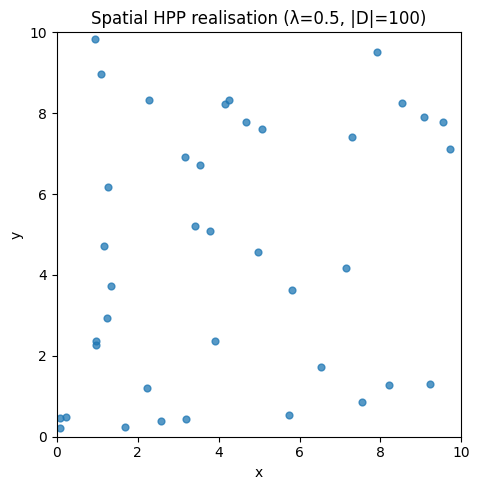

In [3]:
fig, ax = plt.subplots(figsize=(5, 5))
real_locs = locations[mask]
ax.scatter(real_locs[:, 0], real_locs[:, 1], s=24, alpha=0.75, color="C0")
ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_aspect("equal")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_title(f"Spatial HPP realisation (λ={true_rate}, |D|={int(domain_2d.volume())})")
plt.tight_layout()
plt.show()

### Log-likelihood

The joint log-likelihood factorises into a Poisson count term plus an iid-uniform location density:

$$
\log L = \underbrace{n \log \lambda - \lambda |D|}_{\text{count}} \,\, \underbrace{-\, n \log |D|}_{\text{uniform locations}}.
$$

In [4]:
n_events = jnp.sum(mask).astype(jnp.int32)
log_p = hpp_spatial_log_prob(n_events, true_rate, domain_2d.volume())
print(
    f"log L({n_events} events | λ={true_rate}, |D|={float(domain_2d.volume()):.1f}) = {float(log_p):.4f}"
)

log L(39 events | λ=0.5, |D|=100.0) = -256.6344


### Theoretical second-order summaries

Under CSR every closed-form summary has a tidy expression in terms of the spatial dimension $d$. Ripley's $K$-function $K(r) = V_d r^d$ where $V_d$ is the unit-ball volume; Besag's $L$-function $L(r) = (K/V_d)^{1/d} = r$ identically; the pair correlation $g(r) \equiv 1$. Empirical departures from these flat references diagnose clustering ($K(r) > V_d r^d$, $L(r) > r$) or regularity ($K(r) < V_d r^d$, $L(r) < r$).

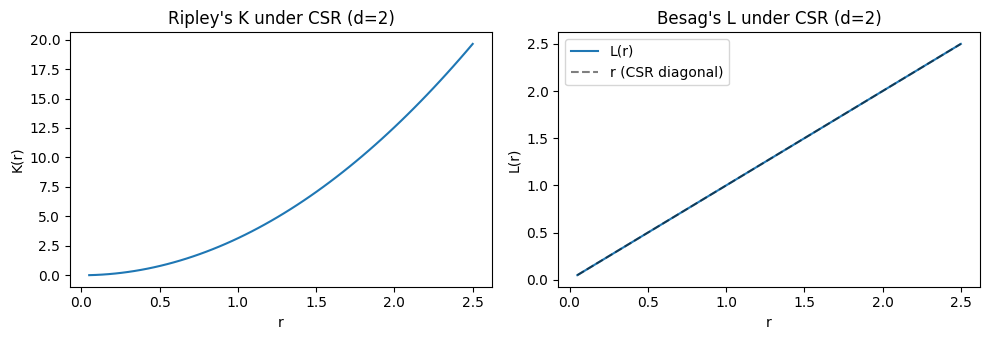

In [5]:
r = jnp.linspace(0.05, 2.5, 60)
K_2d = csr_ripleys_k(r, n_dims=2)
L_2d = csr_l_function(r, n_dims=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
axes[0].plot(r, K_2d, "C0-")
axes[0].set_xlabel("r")
axes[0].set_ylabel("K(r)")
axes[0].set_title("Ripley's K under CSR (d=2)")

axes[1].plot(r, L_2d, "C0-", label="L(r)")
axes[1].plot(r, r, "k--", alpha=0.5, label="r (CSR diagonal)")
axes[1].set_xlabel("r")
axes[1].set_ylabel("L(r)")
axes[1].set_title("Besag's L under CSR (d=2)")
axes[1].legend()
plt.tight_layout()
plt.show()

### Same primitives, $d \in \{1, 2, 3\}$

Nothing in the API changes when we move to 3-D. The intensity and the closed-form summaries scale generically.

In [6]:
for d in (1, 2, 3):
    domain_d = RectangularDomain.from_size(jnp.full((d,), 4.0))
    locs_d, mask_d, _ = hpp_spatial_sample(
        random.PRNGKey(d), rate=0.6, domain=domain_d, max_events=64
    )
    nn = hpp_spatial_nearest_neighbor_distance(rate=0.6, n_dims=d)
    print(
        f"d={d}: |D|={float(domain_d.volume()):.1f}, "
        f"sampled {int(mask_d.sum())} pts, "
        f"E[NN dist] under CSR = {float(nn):.3f}"
    )

d=1: |D|=4.0, sampled 3 pts, E[NN dist] under CSR = 0.833


d=2: |D|=16.0, sampled 10 pts, E[NN dist] under CSR = 0.645


d=3: |D|=64.0, sampled 36 pts, E[NN dist] under CSR = 0.657


## 2. With NumPyro — Bayesian inference for the rate

The same process wraps trivially as a NumPyro `Distribution`. We can recover the unknown $\lambda$ from a single observed pattern using NUTS.

In [7]:
domain = RectangularDomain.from_size(jnp.array([10.0, 10.0]))
true_rate = 0.5
obs_locs, obs_mask, _ = hpp_spatial_sample(
    random.PRNGKey(123), rate=true_rate, domain=domain, max_events=128
)
n_obs = int(obs_mask.sum())
print(f"Observed {n_obs} points in a {int(domain.volume())} m² plot")

Observed 44 points in a 100 m² plot


In [8]:
# NumPyro's ``obs=`` machinery flattens the observation under the hood —
# but the spatial PP "value" is a heterogeneous PyTree ``(locations, mask)``
# rather than a single array, so we score it via ``numpyro.factor`` and
# the operator's ``log_prob`` directly. The data is captured in a closure.
def model():
    rate = numpyro.sample("rate", dist.LogNormal(0.0, 1.0))
    spp = HppSpatialDist(rate=rate, domain=domain, max_events=128)
    numpyro.factor("lik", spp.log_prob((obs_locs, obs_mask)))


mcmc = MCMC(NUTS(model), num_warmup=500, num_samples=1000, progress_bar=False)
mcmc.run(random.PRNGKey(0))
mcmc.print_summary()


                mean       std    median      5.0%     95.0%     n_eff     r_hat
      rate      0.45      0.06      0.45      0.35      0.56    401.03      1.00

Number of divergences: 0


Posterior over $\lambda$ should concentrate around the true value, especially for moderate counts (the precision is $\sim 1/\sqrt{n}$ on the log-rate).

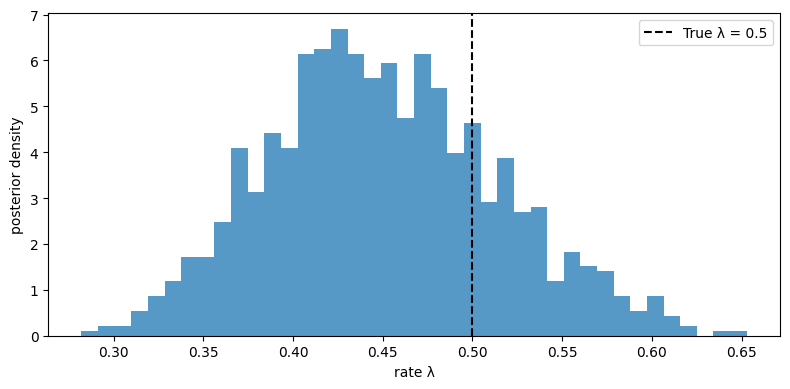

Posterior mean: 0.450, true: 0.5


In [9]:
samples = mcmc.get_samples()["rate"]
fig, ax = plt.subplots()
ax.hist(samples, bins=40, alpha=0.75, density=True)
ax.axvline(true_rate, color="k", linestyle="--", label=f"True λ = {true_rate}")
ax.set_xlabel("rate λ")
ax.set_ylabel("posterior density")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Posterior mean: {float(jnp.mean(samples)):.3f}, true: {true_rate}")

## Where to go from here

- **Inhomogeneous case.** Drop the constant $\lambda$ and let intensity vary across space — the [Inhomogeneous Spatial PP notebook](ipp_spatial_from_scratch_and_numpyro.ipynb) covers thinning samplers, quadrature for $\Lambda(D)$, and posterior inference over a Gaussian-bump intensity field.
- **Marked patterns.** Pair each location with a magnitude or category — the [Marked Spatial PP notebook](marked_spatial_from_scratch_and_numpyro.ipynb) walks through the separable factorisation $\lambda(s, m) = \lambda(s) f(m | s)$ for tree diameters, earthquake magnitudes, and similar applications.